In [6]:
from cirq_sic import *

In [8]:
d = 4
N = 50
thetas = np.linspace(0, np.pi, N)
phis = np.linspace(0, 2*np.pi, N)

def calculate_magic(P, alpha):
    return (1/(1-alpha))*np.log(np.sum(P[:,0]**alpha)) - np.log(d)

def caculate_LTP_deformation(P):
    return np.linalg.norm(np.linalg.pinv(P) - np.eye(d**2))

alpha = 2
exact_magic = np.zeros((N, N))
exact_deform = np.zeros((N, N))

Theta, Phi = np.meshgrid(thetas, phis)
theta_ind = {theta: i for i, theta in enumerate(thetas)}
phi_ind = {phi: i for i, phi in enumerate(phis)}

for theta in thetas:
    for phi in phis:
        fid = np.array([np.cos(theta/2),0,0,np.exp(1j*phi)*np.sin(theta/2)])
        E = wh_povm(fid)
        P = np.array([[(a@b).trace()/b.trace() for b in E] for a in E]).real
        exact_magic[theta_ind[theta], phi_ind[phi]] = calculate_magic(P, alpha)
        exact_deform[theta_ind[theta], phi_ind[phi]] = caculate_LTP_deformation(P)

max_magic = (1/(1-alpha))*np.log((1+(d-1)*(d+1)**(1-alpha))/d)
sic_quantumness = np.linalg.norm(np.eye(d**2) - np.linalg.inv(SIC_P(d)))

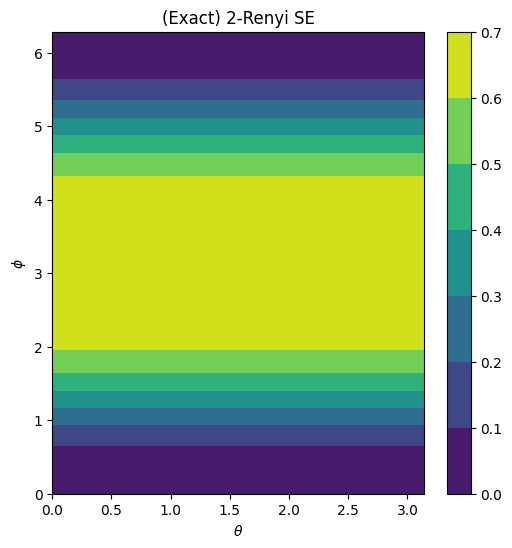

In [9]:
fig, ax = plt.subplots(1, figsize=(6,6))
cs = ax.contourf(Theta, Phi, exact_magic)
fig.colorbar(cs)
ax.set_title("(Exact) %d-Renyi SE" % alpha)
ax.set_xlabel(r"$\theta$")
ax.set_ylabel(r"$\phi$")
fig.savefig("d4_exact_magic.pdf")

In [10]:
cutoff = 50

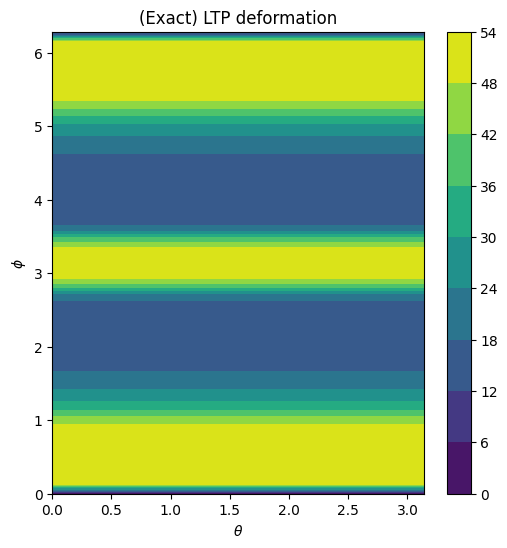

In [12]:
fig, ax = plt.subplots(1, figsize=(6,6))
exact_deform_mat = exact_deform.copy()
exact_deform_mat[exact_deform_mat > cutoff] = cutoff
cs = ax.contourf(Theta, Phi, exact_deform_mat)
fig.colorbar(cs)
ax.set_title("(Exact) LTP deformation")
ax.set_xlabel(r"$\theta$")
ax.set_ylabel(r"$\phi$")
fig.savefig("d4_exact_deform.pdf")